# Average colour per NUTS region, per month

Reads the PNGs produced by the Sentinel-2 pipeline (in `output/<region>/<year>/*.png`),
computes an average RGB colour for each, and lets you filter by year + month before
plotting on a map.

**What's different from the old version:**
- No more GDAL warping/clipping — the pipeline's PNGs are *already* clipped to the
  region shape, with transparent pixels outside (alpha channel), not white padding
- White-pixel filtering replaced with alpha filtering — no more confusing snow/clouds
  with region outline
- Everything is a single DataFrame keyed by `(nuts_id, year, month)` so filtering
  works with normal pandas indexing


## 1. Setup

In [43]:
import os
import re
import numpy as np
import pandas as pd
import geopandas as gpd
from PIL import Image

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [44]:
OUTPUT_DIR = "output"                              # where the pipeline wrote PNGs
NUTS_GEOJSON = "NUTS_RG_20M_2024_4326.geojson"     # same file as the pipeline uses
nuts_gdf = gpd.read_file(NUTS_GEOJSON)

## 2. Index the images

Walks `output/` and returns one row per PNG with its NUTS ID, year and month parsed
from the filename.

In [45]:
def scan_images(output_dir=OUTPUT_DIR):
    """Return a DataFrame with columns: region, nuts_id, year, month, path.

    Assumes the pipeline's structure:
      output/<region_folder>/<year>/<region_folder>_YYYY-MM-01.png
    """
    rows = []
    for region in os.listdir(output_dir):
        region_path = os.path.join(output_dir, region)
        if not os.path.isdir(region_path):
            continue
        for year_str in os.listdir(region_path):
            year_path = os.path.join(region_path, year_str)
            if not os.path.isdir(year_path):
                continue
            for fname in os.listdir(year_path):    # ← indented
                m = re.search(r"_(\d{4})-(\d{2})-\d{2}\.png$", fname)
                if not m:
                    continue
                nuts_id = region.split("_", 1)[0]
                rows.append({
                    "region": region,
                    "nuts_id": nuts_id,
                    "level": len(nuts_id) - 2,
                    "year": int(m.group(1)),
                    "month": int(m.group(2)),
                    "path": os.path.join(year_path, fname),
                })
    return pd.DataFrame(rows) 


index_df = scan_images()
print(f"Found {len(index_df)} images across {index_df['nuts_id'].nunique()} regions")
index_df.head()

Found 180 images across 36 regions


,region,nuts_id,level,year,month,path
0,XK_Kosovo -,XK,0,2022,7,output/XK_Kosovo - /2022/XK_Kosovo - _2022-07-...
1,XK_Kosovo -,XK,0,2025,7,output/XK_Kosovo - /2025/XK_Kosovo - _2025-07-...
2,XK_Kosovo -,XK,0,2024,7,output/XK_Kosovo - /2024/XK_Kosovo - _2024-07-...
3,XK_Kosovo -,XK,0,2023,7,output/XK_Kosovo - /2023/XK_Kosovo - _2023-07-...
4,XK_Kosovo -,XK,0,2026,7,output/XK_Kosovo - /2026/XK_Kosovo - _2026-07-...


## 3. Compute the average colour

Reads each PNG in RGBA mode, ignores transparent pixels (outside the region + masked
clouds), and averages the RGB. Optional near-white threshold catches any residual
clouds that survived the SCL mask.

In [46]:
def calculate_average_color(image_path, white_threshold=245):
    """Return (r, g, b) mean over opaque, non-white pixels. None if nothing valid."""
    try:
        with Image.open(image_path) as img:
            arr = np.array(img.convert("RGBA"))
    except Exception as e:
        print(f"Couldn't read {image_path}: {e}")
        return None

    rgb = arr[:, :, :3]
    alpha = arr[:, :, 3]

    opaque = alpha > 0
    not_white = np.any(rgb < white_threshold, axis=-1)
    mask = opaque & not_white

    if not mask.any():
        return None
    return tuple(rgb[mask].mean(axis=0).astype(int))


def rgb_to_hex(rgb):
    return "#{:02x}{:02x}{:02x}".format(*rgb) if rgb is not None else None

## 4. Build the colour DataFrame

Filter the image index by year/month first, then compute — that way you're not
processing images you don't care about.

In [47]:
def build_color_dataframe(months=None, years=None, regions=None, level=None,
                          output_dir=OUTPUT_DIR, white_threshold=245):
    """Compute average colours for the subset matching the filters.

    months  : list of month numbers (1-12), or None for all
    years   : list of years, or None for all
    regions : list of NUTS IDs, or None for all
    """
    df = scan_images(output_dir)
    if level is not None: df = df[df["level"] == level]
    if months:            df = df[df["month"].isin(months)]
    if years:   df = df[df["year"].isin(years)]
    if regions: df = df[df["nuts_id"].isin(regions)]

    df = df.copy()
    df["rgb"] = df["path"].apply(lambda p: calculate_average_color(p, white_threshold))
    df["hex"] = df["rgb"].apply(rgb_to_hex)
    df = df.dropna(subset=["hex"]).reset_index(drop=True)
    return df


# Example: July 2024 across all regions
july_2024 = build_color_dataframe(months=[7], years=[2024])
july_2024.head()

,region,nuts_id,level,year,month,path,rgb,hex
0,XK_Kosovo -,XK,0,2024,7,output/XK_Kosovo - /2024/XK_Kosovo - _2024-07-...,"(47, 53, 33)",#2f3521
1,AL_Shqipëria,AL,0,2024,7,output/AL_Shqipëria/2024/AL_Shqipëria_2024-07-...,"(60, 63, 41)",#3c3f29
2,CH_Schweiz - Suisse - Svizzera,CH,0,2024,7,output/CH_Schweiz - Suisse - Svizzera/2024/CH_...,"(58, 70, 50)",#3a4632
3,CZ_Česko,CZ,0,2024,7,output/CZ_Česko/2024/CZ_Česko_2024-07-01.png,"(50, 54, 37)",#323625
4,EE_Eesti,EE,0,2024,7,output/EE_Eesti/2024/EE_Eesti_2024-07-01.png,"(31, 43, 31)",#1f2b1f


## 5. Averaging across months (for seasonal comparisons)

If you want e.g. "summer 2023" as one colour per region, average the RGB values across
the months in the group and re-hexify.

In [48]:
'''def aggregate_colors(df, by=("nuts_id", "year")):
    """Average RGB across rows within each group; return one row per group."""
    def mean_color(sub):
        arr = np.array(sub["rgb"].tolist())
        return tuple(arr.mean(axis=0).astype(int))

    grouped = (df.groupby(list(by))
                 .apply(mean_color, include_groups=False)
                 .rename("rgb")
                 .reset_index())
    grouped["hex"] = grouped["rgb"].apply(rgb_to_hex)
    return grouped


# Example: summer average per region-year
summer = build_color_dataframe(months=[6, 7, 8])
summer_avg = aggregate_colors(summer, by=("nuts_id", "year"))
summer_avg.head()'''

'def aggregate_colors(df, by=("nuts_id", "year")):\n    """Average RGB across rows within each group; return one row per group."""\n    def mean_color(sub):\n        arr = np.array(sub["rgb"].tolist())\n        return tuple(arr.mean(axis=0).astype(int))\n\n    grouped = (df.groupby(list(by))\n                 .apply(mean_color, include_groups=False)\n                 .rename("rgb")\n                 .reset_index())\n    grouped["hex"] = grouped["rgb"].apply(rgb_to_hex)\n    return grouped\n\n\n# Example: summer average per region-year\nsummer = build_color_dataframe(months=[6, 7, 8])\nsummer_avg = aggregate_colors(summer, by=("nuts_id", "year"))\nsummer_avg.head()'

## 6. Plot on a map

Same cartopy setup as before, but takes any of the DataFrames above. Pass one that has
exactly one row per NUTS ID (i.e. filtered to a single month+year, or aggregated).

In [49]:
def plot_color_map(color_df, nuts_gdf=nuts_gdf, title=None,
                   extent=(-25, 50, 30, 80), save_path=None):
    """color_df must have columns nuts_id and hex, one row per region."""
    if color_df["nuts_id"].duplicated().any():
        raise ValueError("color_df has multiple rows per NUTS ID — aggregate or filter first")

    merged = nuts_gdf.merge(color_df[["nuts_id", "hex"]],
                            left_on="NUTS_ID", right_on="nuts_id", how="inner")

    fig, ax = plt.subplots(figsize=(15, 15), subplot_kw={
        "projection": ccrs.LambertAzimuthalEqualArea(central_longitude=10, central_latitude=55)
    })
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.BORDERS.with_scale("50m"), edgecolor="black")
    ax.add_feature(cfeature.OCEAN, facecolor="white")
    ax.add_feature(cfeature.LAND.with_scale("50m"))
    ax.add_feature(cfeature.COASTLINE.with_scale("50m"))

    for _, row in merged.iterrows():
        ax.add_geometries([row["geometry"]], crs=ccrs.PlateCarree(),
                          facecolor=row["hex"], edgecolor="black", linewidth=0.3)

    if title:
        ax.set_title(title, fontsize=14)
    if save_path:
        plt.savefig(save_path, format=save_path.split(".")[-1], bbox_inches="tight")
    plt.show()

## 7. Usage examples

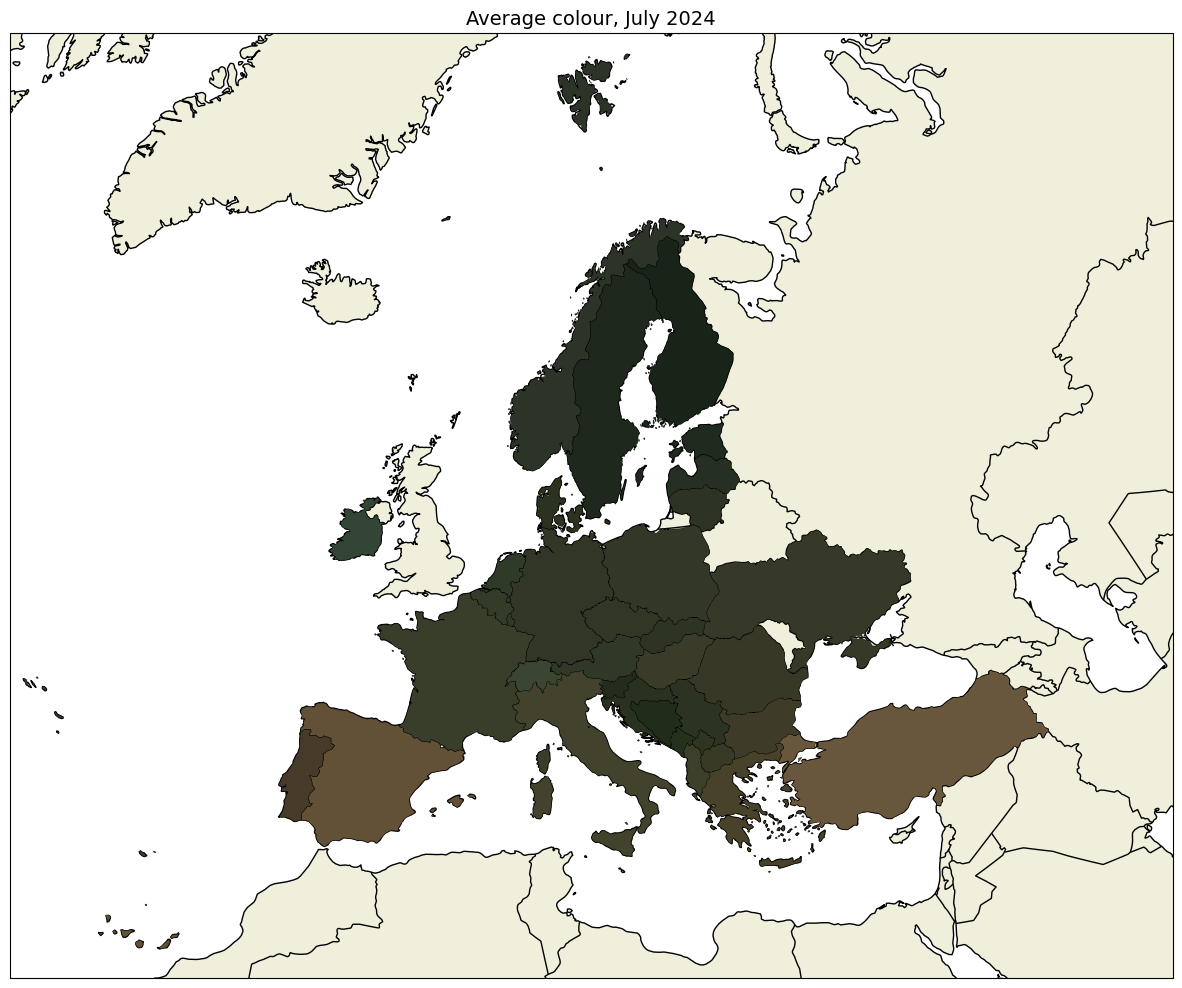

In [50]:
# A) Single month + year — one snapshot map
df = build_color_dataframe(months=[7], years=[2024], level = 0)
plot_color_map(df, title="Average colour, July 2024",
               save_path="avg_color_2024-07.svg")

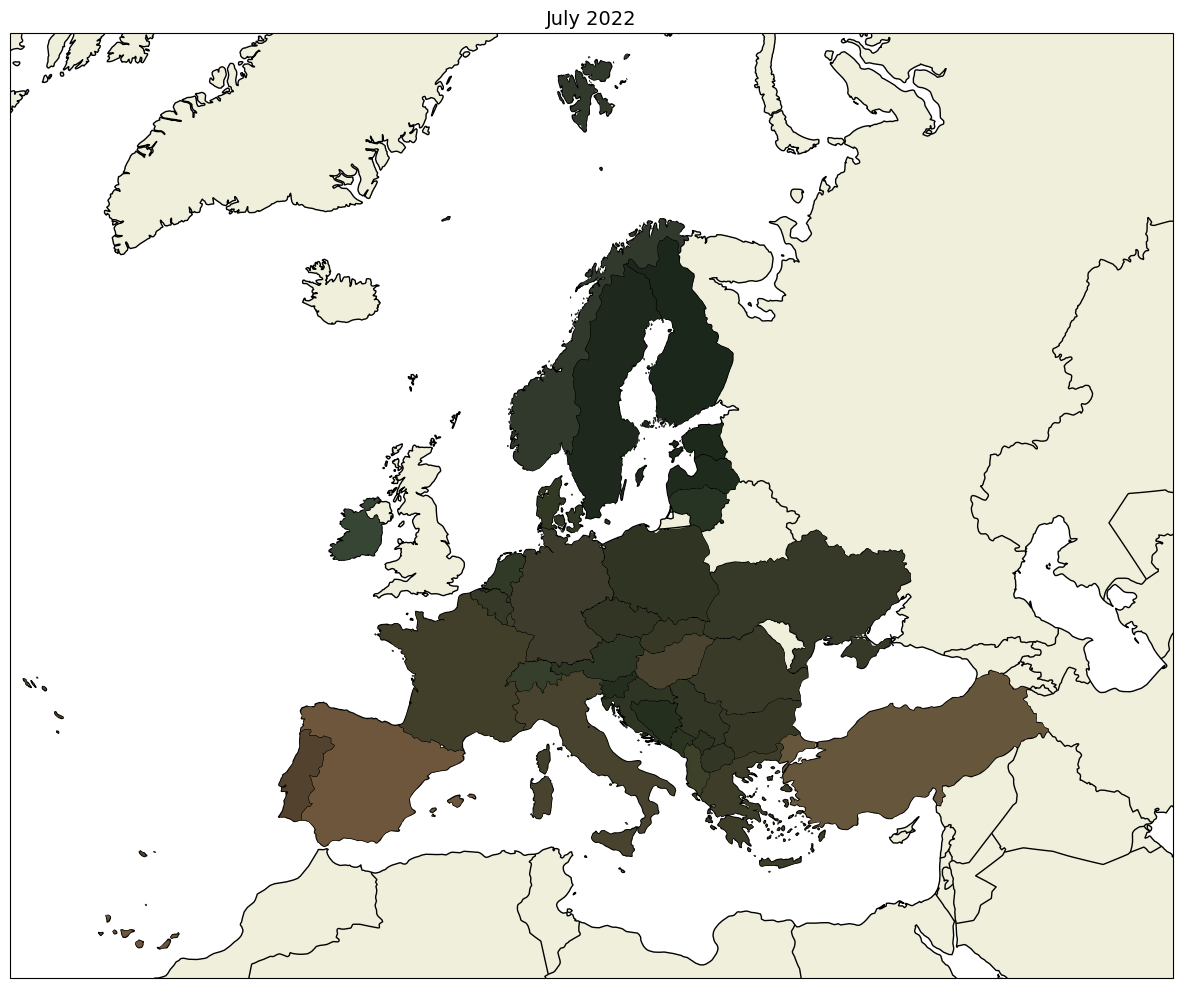

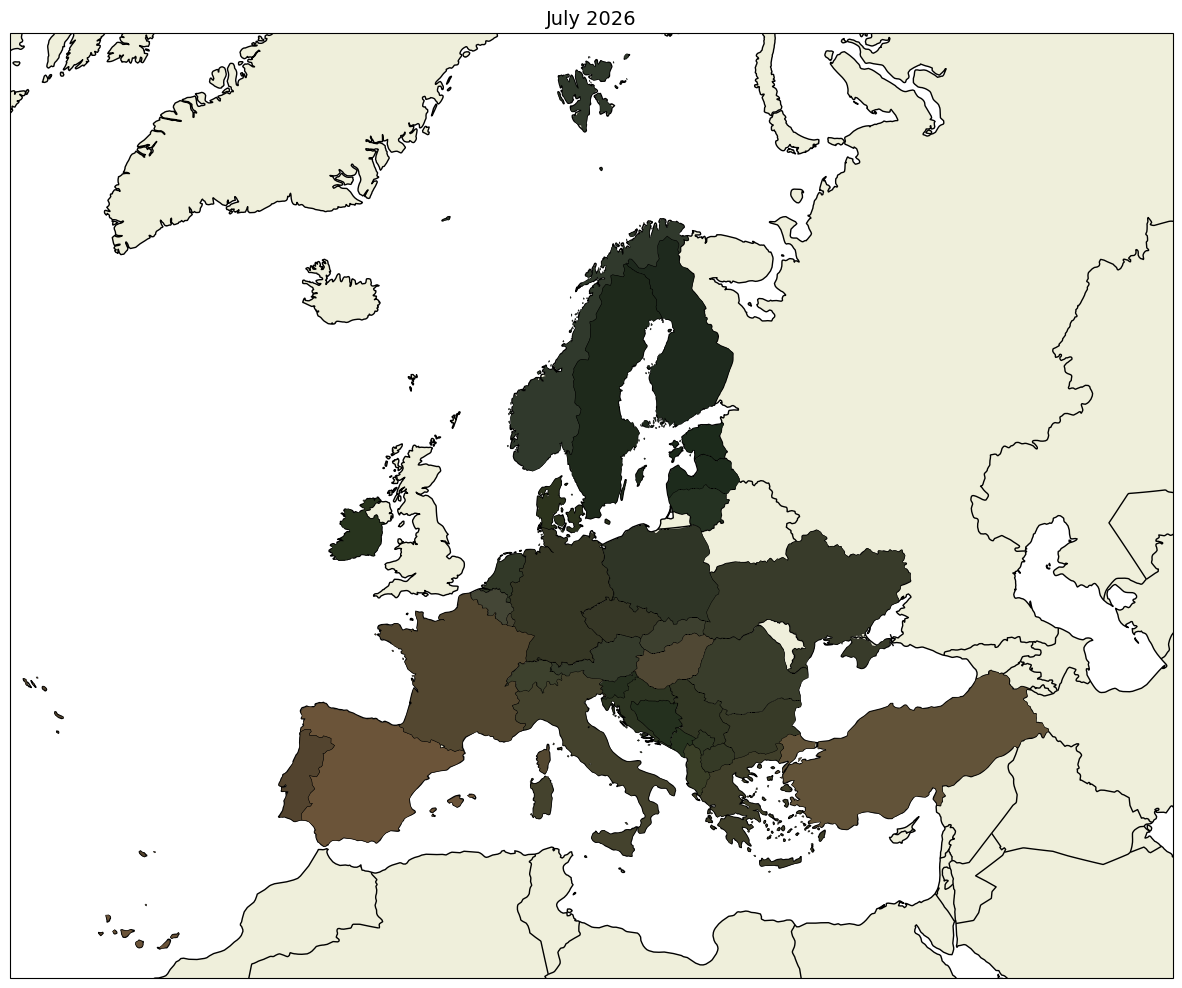

In [51]:
# C) Side-by-side: same month across multiple years
# Loop over years and save one SVG each
for year in [2022, 2026]:
    df = build_color_dataframe(months=[7], years=[year], level=0)
    if len(df) == 0:
        continue
    plot_color_map(df, title=f"July {year}",
                   save_path=f"avg_color_{year}-07.svg")

In [52]:
# D) Track one region across all months — a time series of colours
region_df = build_color_dataframe(regions=["ES13"])   # Madrid
region_df = region_df.sort_values(["year", "month"])
region_df[["year", "month", "hex"]]

,year,month,hex


## 8. Notes / gotchas

- **Alpha vs white:** with the new pipeline, outside-region pixels are transparent
  (alpha=0), so the alpha check is what actually filters them. The `white_threshold`
  parameter mostly catches lingering clouds — raise it to include lighter pixels
  (255 = disable), lower it to exclude bright surfaces (careful with snow in winter
  months, which will bias the average toward white).
- **Missing regions on the map:** happens if a region has no PNG for that
  month/year, or all its pixels were masked. `plot_color_map` just skips them via
  the inner join.
- **Colour averaging in RGB is naïve** — a mix of green and red doesn't produce
  yellow, it produces brown. For accurate perceptual averaging you'd work in Lab or
  HSV space, but for green-vs-brown drought comparisons RGB is fine because the
  colour axis you care about is already close to a straight line in RGB.
